In [ ]:
import random
import pandas as pd

products = ['Laptop', 'Smartphone', 'Headphones', 'Keyboard', 'Mouse', 'Monitor', 'Printer', 'Tablet', 'Camera', 'Speaker']
customers = ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Hannah', 'Ivy', 'Jack']
delivery_destinations = ['Station 1', 'Station 2', 'Station 3', 'Station 4', 'Station 5', 
                         'Station 6', 'Station 7', 'Station 8', 'Station 9', 'Station 10']
pods = [f'Pod {i}' for i in range(1, 11)]

def generate_orders(num_orders):
    orders = []
    for order_id in range(1, num_orders+1):
        product_name = random.choice(products)
        customer_name = random.choice(customers)
        product_size = round(random.uniform(0.5, 10.0), 2)  # Volume in cubic units
        product_weight = round(random.uniform(1.0, 20.0), 2)  # Weight in kg
        delivery_destination = random.choice(delivery_destinations)
        pod_shelf_number = random.choice(pods)
        
        orders.append({
            'Order ID': order_id,
            'Product Name': product_name,
            'Customer Name': customer_name,
            'Product Size (Volume)': product_size,
            'Product Weight': product_weight,
            'Delivery Destination': delivery_destination,
            'Pod Shelf Number': pod_shelf_number
        })
    
    return pd.DataFrame(orders)

orders_df = generate_orders(1000)
print(orders_df.head())

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# Encode categorical features (Product Name, Delivery Destination, Pod Shelf Number)
label_encoders = {}
for col in ['Product Name', 'Delivery Destination', 'Pod Shelf Number']:
    le = LabelEncoder()
    orders_df[col] = le.fit_transform(orders_df[col])
    label_encoders[col] = le

X = orders_df[['Product Size (Volume)', 'Product Weight', 'Delivery Destination']]
y = orders_df['Pod Shelf Number']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(orders_df['Product Size (Volume)'], bins=20, kde=True)
plt.title('Product Size (Volume) Distribution')

plt.subplot(1, 2, 2)
sns.histplot(orders_df['Product Weight'], bins=20, kde=True)
plt.title('Product Weight Distribution')

plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(x='Delivery Destination', data=orders_df)
plt.title('Count of Orders per Delivery Destination')
plt.show()

In [ ]:
# Feature importance from Random Forest
importances = clf.feature_importances_
features = X.columns

# Plot feature importance
plt.figure(figsize=(8, 6))
sns.barplot(x=importances, y=features)
plt.title('Feature Importance')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoders['Pod Shelf Number'].classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [12]:
# Dimensionality reduction
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

# Clustering using KMeans
kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(X_reduced)

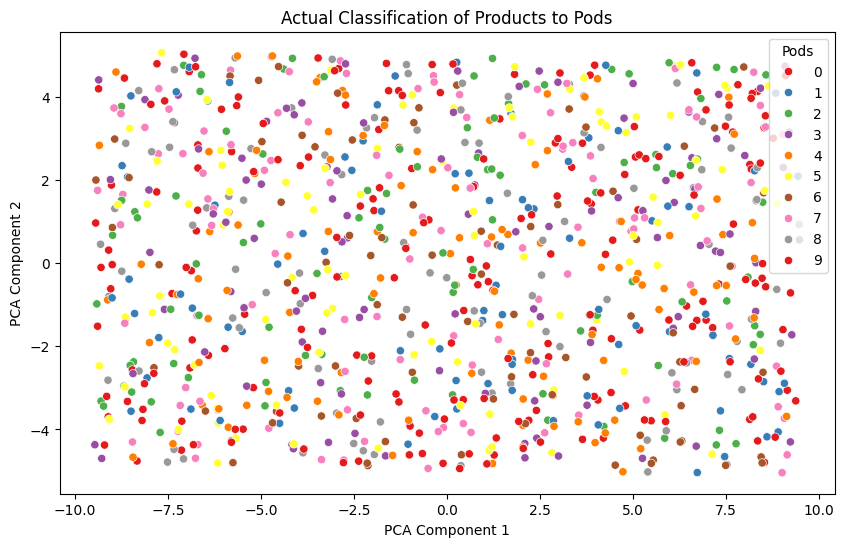

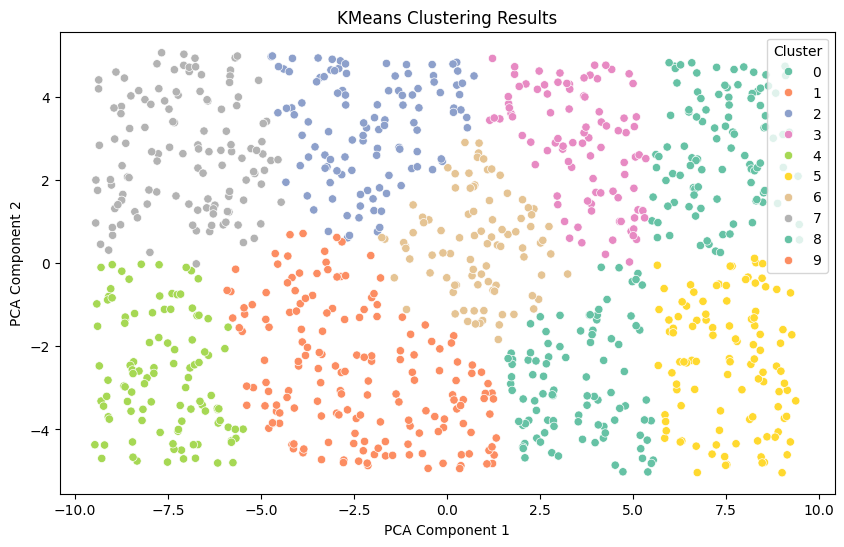

In [13]:
# Plot actual classification (True Pod)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_reduced[:, 0], y=X_reduced[:, 1], hue=y, palette='Set1', legend='full')
plt.title('Actual Classification of Products to Pods')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Pods', loc='best')
plt.show()

# Plot clustering results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_reduced[:, 0], y=X_reduced[:, 1], hue=clusters, palette='Set2', legend='full')
plt.title('KMeans Clustering Results')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster', loc='best')
plt.show()